# Assingment#3: Transformers+RAG
## Name: Arqam Zulfiqar     Roll#: 23I-2608    Section: C

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Data Loading & Subset Creation:

In [2]:
import json
import gzip
import random
from collections import Counter

# Configuration
CATEGORIES = ['electronics', 'beauty', 'home']
SAMPLES_PER_CATEGORY = 15000
MAX_SEQ_LEN = 128  # You can adjust this based on GPU memory

def load_amazon_data(file_path, category_label):
    data = []
    with gzip.open(file_path, 'rt') as f:
        for line in f:
            item = json.loads(line)
            text = item.get('reviewText', '')
            rating = item.get('overall', 0)

            if text and rating:
                # Part A Sentiment Mapping: 1-2 Neg (0), 3 Neut (1), 4-5 Pos (2)
                if rating <= 2: sentiment = 0
                elif rating == 3: sentiment = 1
                else: sentiment = 2

                data.append({
                    'text': text.lower(),
                    'sentiment': sentiment,
                    'category': category_label
                })
    return random.sample(data, min(len(data), SAMPLES_PER_CATEGORY))

# Load and combine
raw_dataset = []
for i, cat in enumerate(CATEGORIES):
    # Ensure you have these files in your directory
    raw_dataset.extend(load_amazon_data(f'/content/drive/MyDrive/NLP_Assignment3/{cat}.json.gz', i))

random.shuffle(raw_dataset)

## Step 2: Custom Tokenization & Vocabulary:

In [3]:
class SimpleTokenizer:
    def __init__(self, vocab_size=20000):
        self.vocab_size = vocab_size
        self.word2idx = {"[PAD]": 0, "[UNK]": 1, "[SOS]": 2, "[EOS]": 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}

    def build_vocab(self, sentences):
        word_counts = Counter()
        for s in sentences:
            word_counts.update(s.split())

        most_common = word_counts.most_common(self.vocab_size - 4)
        for word, _ in most_common:
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, text, max_len):
        tokens = text.split()[:max_len-2]
        token_ids = [self.word2idx["[SOS]"]] + \
                    [self.word2idx.get(t, self.word2idx["[UNK]"]) for t in tokens] + \
                    [self.word2idx["[EOS]"]]

        # Padding
        padding_len = max_len - len(token_ids)
        token_ids += [self.word2idx["[PAD]"]] * padding_len
        return token_ids

# Split Data (70/15/15)
train_idx = int(0.7 * len(raw_dataset))
val_idx = int(0.85 * len(raw_dataset))

train_data = raw_dataset[:train_idx]
val_data = raw_dataset[train_idx:val_idx]
test_data = raw_dataset[val_idx:]

# Build vocab ONLY from training data
tokenizer = SimpleTokenizer()
tokenizer.build_vocab([d['text'] for d in train_data])

## Step 3: The Transformer Building Blocks (Part A):

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0

        self.d_k = d_model // num_heads

        # Wq, Wk, Wv projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size = x.size(0)

        # Linear projections and split into heads
        q = self.W_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Scaled Dot-Product Attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = F.softmax(scores, dim=-1)
        context = torch.matmul(attn, v) # (batch, heads, seq, d_k)

        # Concatenate heads
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(context)

## Step 4: Position-wise Feed-Forward & Encoder Block:

In [5]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Sublayer 1: Attention + Residual + Norm
        attn_out = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        # Sublayer 2: Feed Forward + Residual + Norm
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

##  Step 5: The Multi-Task Transformer Encoder:

In [6]:
class MultiTaskEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.zeros(1, max_len, d_model))

        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

        # Multi-task heads
        self.sentiment_head = nn.Linear(d_model, 3) # Neg, Neut, Pos
        self.category_head = nn.Linear(d_model, 3)  # Beauty, Electronics, Home

    def forward(self, x, mask=None):
        # Add embedding and positional info
        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]

        for layer in self.layers:
            x = layer(x, mask)

        # Global Average Pooling to get the "fixed-dimensional vector representation"
        # This pooled_output is what we will save for Part B retrieval
        pooled_output = torch.mean(x, dim=1)

        sentiment_logits = self.sentiment_head(pooled_output)
        category_logits = self.category_head(pooled_output)

        return sentiment_logits, category_logits, pooled_output

## Step 6: Training Pipeline & Combined Loss:

In [7]:
# Hyperparameters
D_MODEL = 256
NUM_LAYERS = 4
NUM_HEADS = 8
D_FF = 512
LEARNING_RATE = 1e-4

model = MultiTaskEncoder(len(tokenizer.word2idx), D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF, MAX_SEQ_LEN)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

def train_step(batch_tokens, batch_sentiment, batch_category):
    model.train()
    optimizer.zero_grad()

    # Generate padding mask (masking out [PAD] tokens so attention ignores them)
    mask = (batch_tokens != 0).unsqueeze(1).unsqueeze(2) # (batch, 1, 1, seq_len)

    s_logits, c_logits, _ = model(batch_tokens, mask)

    loss_s = criterion(s_logits, batch_sentiment)
    loss_c = criterion(c_logits, batch_category)

    total_loss = loss_s + loss_c # Combined Loss
    total_loss.backward()
    optimizer.step()

    return total_loss.item()

## Step#7: Training Loop & Metric Tracking:

In [8]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Convert data to Tensors (assuming you have 'tokenizer', 'train_data', etc. from previous steps)
def prepare_tensor_data(data_list):
    tokens = torch.tensor([tokenizer.encode(d['text'], MAX_SEQ_LEN) for d in data_list])
    sentiments = torch.tensor([d['sentiment'] for d in data_list])
    categories = torch.tensor([d['category'] for d in data_list])
    return TensorDataset(tokens, sentiments, categories)

train_loader = DataLoader(prepare_tensor_data(train_data), batch_size=32, shuffle=True)
val_loader = DataLoader(prepare_tensor_data(val_data), batch_size=32)

# History for plotting
history = {'loss': [], 'sent_acc': [], 'cat_acc': []}

epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Starting training on {device}...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct_s, correct_c, total = 0, 0, 0

    for batch in train_loader:
        b_tokens, b_sent, b_cat = [t.to(device) for t in batch]

        optimizer.zero_grad()
        mask = (b_tokens != 0).unsqueeze(1).unsqueeze(2).to(device)

        s_logits, c_logits, _ = model(b_tokens, mask)

        loss_s = criterion(s_logits, b_sent)
        loss_c = criterion(c_logits, b_cat)
        loss = loss_s + loss_c

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Calculate Accuracy
        correct_s += (s_logits.argmax(1) == b_sent).sum().item()
        correct_c += (c_logits.argmax(1) == b_cat).sum().item()
        total += b_tokens.size(0)

    # Save metrics
    history['loss'].append(total_loss / len(train_loader))
    history['sent_acc'].append(correct_s / total)
    history['cat_acc'].append(correct_c / total)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {history['loss'][-1]:.4f} - Sent Acc: {history['sent_acc'][-1]:.4f} - Cat Acc: {history['cat_acc'][-1]:.4f}")

Starting training on cuda...
Epoch 1/5 - Loss: 1.2007 - Sent Acc: 0.8040 - Cat Acc: 0.7165
Epoch 2/5 - Loss: 0.8072 - Sent Acc: 0.8185 - Cat Acc: 0.8802
Epoch 3/5 - Loss: 0.6774 - Sent Acc: 0.8315 - Cat Acc: 0.9175
Epoch 4/5 - Loss: 0.5850 - Sent Acc: 0.8434 - Cat Acc: 0.9397
Epoch 5/5 - Loss: 0.5045 - Sent Acc: 0.8561 - Cat Acc: 0.9572


## Step#8: Generating the Required Curves:

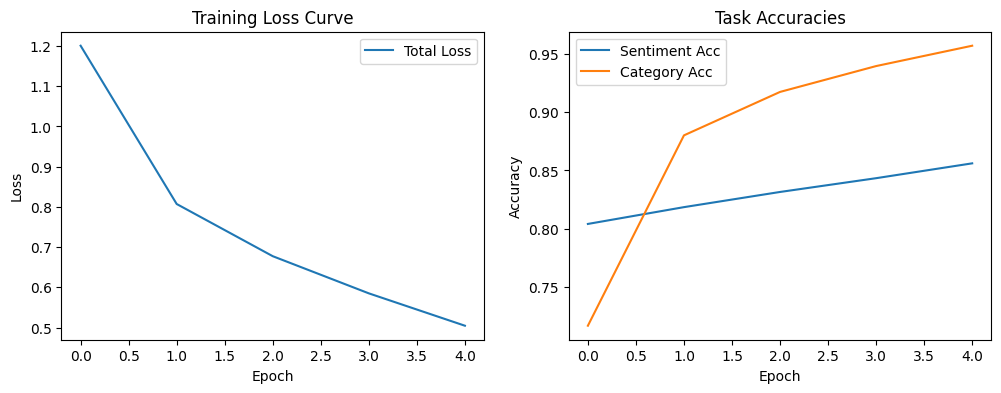

In [9]:
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Total Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracies
plt.subplot(1, 2, 2)
plt.plot(history['sent_acc'], label='Sentiment Acc')
plt.plot(history['cat_acc'], label='Category Acc')
plt.title('Task Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Step#9: Saving the Embeddings:

In [10]:
model.eval()
all_embeddings = []
with torch.no_grad():
    # We save embeddings for the TRAINING set for retrieval purposes
    full_train_loader = DataLoader(prepare_tensor_data(train_data), batch_size=32)
    for batch in full_train_loader:
        tokens = batch[0].to(device)
        mask = (tokens != 0).unsqueeze(1).unsqueeze(2)
        _, _, embeddings = model(tokens, mask)
        all_embeddings.append(embeddings.cpu())

# Concatenate and save
train_embeddings = torch.cat(all_embeddings, dim=0)
torch.save(train_embeddings, 'train_embeddings.pt')
print("Embeddings saved for Part B!")

Embeddings saved for Part B!


## Test Evaluation:

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

###################################################
# PART A TEST EVALUATION
###################################################

test_loader = DataLoader(
    prepare_tensor_data(test_data),
    batch_size=64
)

model.eval()

true_sent = []
pred_sent = []

true_cat = []
pred_cat = []

with torch.no_grad():

    for batch in test_loader:

        tokens, s, c = [x.to(device) for x in batch]

        mask = (tokens != 0).unsqueeze(1).unsqueeze(2)

        s_logits, c_logits, _ = model(tokens, mask)

        ps = s_logits.argmax(1)
        pc = c_logits.argmax(1)

        true_sent.extend(s.cpu().numpy())
        pred_sent.extend(ps.cpu().numpy())

        true_cat.extend(c.cpu().numpy())
        pred_cat.extend(pc.cpu().numpy())

###################################################
# Sentiment Metrics
###################################################

acc = accuracy_score(true_sent, pred_sent)

p,r,f,_ = precision_recall_fscore_support(
    true_sent,
    pred_sent,
    average='macro'
)

print("===== PART A TEST RESULTS =====")
print("Sentiment Accuracy :", round(acc,4))
print("Precision          :", round(p,4))
print("Recall             :", round(r,4))
print("F1 Score           :", round(f,4))

print("\nSentiment Confusion Matrix:")
print(confusion_matrix(true_sent, pred_sent))

###################################################
# Category Metrics
###################################################

acc2 = accuracy_score(true_cat, pred_cat)

p2,r2,f2,_ = precision_recall_fscore_support(
    true_cat,
    pred_cat,
    average='macro'
)

print("\nCategory Accuracy :", round(acc2,4))
print("Precision         :", round(p2,4))
print("Recall            :", round(r2,4))
print("F1 Score          :", round(f2,4))

print("\nCategory Confusion Matrix:")
print(confusion_matrix(true_cat, pred_cat))

===== PART A TEST RESULTS =====
Sentiment Accuracy : 0.8184
Precision          : 0.5954
Recall             : 0.5232
F1 Score           : 0.5446

Sentiment Confusion Matrix:
[[ 324   60  335]
 [  89  111  426]
 [ 202  114 5089]]

Category Accuracy : 0.8899
Precision         : 0.8912
Recall            : 0.8897
F1 Score          : 0.8899

Category Confusion Matrix:
[[2118   45  125]
 [ 104 1986  130]
 [ 231  108 1903]]


# Part B: Retrieval Module:

## Step 1: Loading and Indexing Embeddings:

In [14]:
import torch.nn.functional as F

class ReviewRetriever:
    def __init__(self, train_embeddings, train_data, k=3):
        """
        train_embeddings: Tensor of shape [N, D_MODEL]
        train_data: The list of raw training samples (to get the text)
        k: Number of neighbors to retrieve
        """
        self.embeddings = train_embeddings.to(device) # Move embeddings to the correct device
        self.train_data = train_data
        self.k = k

    def retrieve(self, query_embedding):
        """
        query_embedding: Tensor of shape [1, D_MODEL]
        """
        # Calculate Cosine Similarity: (A · B) / (||A|| * ||B||)
        # We can use F.cosine_similarity or manual dot product on normalized vectors
        sim_scores = F.cosine_similarity(query_embedding, self.embeddings)

        # Get top-k indices
        top_k_val, top_k_idx = torch.topk(sim_scores, self.k)

        results = []
        for idx in top_k_idx:
            results.append(self.train_data[idx.item()])

        return results, top_k_val

# Initialize Retriever
retriever = ReviewRetriever(train_embeddings, train_data, k=3)

## Step 2: Testing the Retrieval:

In [15]:
def test_retrieval_quality(num_samples=2):
    model.eval()
    for i in range(num_samples):
        sample = test_data[i]
        text = sample['text']

        # 1. Build Query Representation
        tokens = torch.tensor([tokenizer.encode(text, MAX_SEQ_LEN)]).to(device)
        mask = (tokens != 0).unsqueeze(1).unsqueeze(2)

        with torch.no_grad():
            _, _, query_embedding = model(tokens, mask)

        # 2. Search
        neighbors, scores = retriever.retrieve(query_embedding)

        print(f"--- Query Review (Category: {sample['category']}) ---")
        print(f"Text: {text[:150]}...")
        print(f"\n--- Top {retriever.k} Retrieved Neighbors ---")
        for n, score in zip(neighbors, scores):
            print(f"[{score.item():.4f}] (Cat: {n['category']}) {n['text'][:100]}...")
        print("-" * 50)

test_retrieval_quality()

--- Query Review (Category: 2) ---
Text: its expensive, but considering how much easier it makes it to make pasta (and how much better homemade pasta tastes) it is worth the money. while it t...

--- Top 3 Retrieved Neighbors ---
[0.8687] (Cat: 2) most of the colanders i see in the store are in two parts, with the handle being a separate piece, a...
[0.8609] (Cat: 2) this makes making coffee so much better.  we always had trouble with the paper filters falling over ...
[0.8607] (Cat: 2) i have really liked this pail.  no odors at all and don't have to change filters very often either. ...
--------------------------------------------------
--- Query Review (Category: 1) ---
Text: this cleanser is very silky and  keeps your face really smooth. i love it and it smells nice. i would suggest you get it because loreal is always a ni...

--- Top 3 Retrieved Neighbors ---
[0.9432] (Cat: 1) i love this! it smells amazing without all the harsh perfumes that normally accompanying shampoos th...
[

# Part C: Decoder Model for Explanation Generation:

## Decoder Architecture:

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CausalMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.size()

        q = self.W_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_k ** 0.5)

        # --- CRITICAL: CAUSAL MASKING (Part C Requirement) ---
        causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(x.device)
        scores = scores.masked_fill(causal_mask, -1e9)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = F.softmax(scores, dim=-1)
        output = torch.matmul(attn, v).transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(output)

class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = CausalMultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout) # Reusing FeedForward from Part A
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, mask)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x

class ExplanationDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.zeros(1, max_len, d_model))
        self.layers = nn.ModuleList([DecoderBlock(d_model, num_heads, d_ff) for _ in range(num_layers)])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None):
        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]
        for layer in self.layers:
            x = layer(x, mask)
        return self.fc_out(x)

## RAG Input Construction:

In [18]:
from torch.utils.data import DataLoader

def build_prompt_from_encoder(item, use_retrieval=True):
    """
    Uses Part A encoder predictions + real retrieval embeddings
    """

    sent_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    cat_map = {0: "Electronics", 1: "Beauty", 2: "Home"}

    model.eval()

    # Encode review text
    tokens = torch.tensor(
        [tokenizer.encode(item['text'], MAX_SEQ_LEN)],
        dtype=torch.long
    ).to(device)

    mask = (tokens != 0).unsqueeze(1).unsqueeze(2)

    with torch.no_grad():
        s_logits, c_logits, embedding = model(tokens, mask)

    pred_sent = s_logits.argmax(1).item()
    pred_cat  = c_logits.argmax(1).item()

    # Real Retrieval
    if use_retrieval:
        context_samples, _ = retriever.retrieve(embedding) # Removed .cpu() here
        context_text = " ".join([x['text'][:50] for x in context_samples])
    else:
        context_text = "No retrieved context."

    prompt = (
        f"Review: {item['text'][:80]} | "
        f"Sentiment: {sent_map[pred_sent]} | "
        f"Category: {cat_map[pred_cat]} | "
        f"Context: {context_text} | "
        f"Explanation:"
    )

    return prompt


def prepare_rag_dataset(data_list, use_retrieval=True, limit=5000):
    sequences = []

    for item in data_list[:limit]:

        prompt = build_prompt_from_encoder(item, use_retrieval)

        target = item.get(
            "summary",
            "this review supports the predicted sentiment."
        )

        full_text = prompt + " " + target

        ids = tokenizer.encode(full_text, MAX_SEQ_LEN)
        sequences.append(ids)

    return torch.tensor(sequences, dtype=torch.long)


# Build train loader (FULL RAG)
train_decoder_tensors = prepare_rag_dataset(
    train_data,
    use_retrieval=True,
    limit=5000
)

decoder_loader = DataLoader(
    train_decoder_tensors,
    batch_size=32,
    shuffle=True
)

## Training and Perplexity:

In [19]:
import math

decoder_model = ExplanationDecoder(
    len(tokenizer.word2idx),
    D_MODEL,
    4,
    8,
    512,
    MAX_SEQ_LEN
).to(device)

optimizer = torch.optim.Adam(decoder_model.parameters(), lr=1e-4)

criterion = nn.CrossEntropyLoss(
    ignore_index=tokenizer.word2idx["[PAD]"]
)

print("Training Decoder...")

for epoch in range(3):

    decoder_model.train()
    total_loss = 0

    for batch in decoder_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        logits = decoder_model(batch[:, :-1])

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            batch[:, 1:].reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(decoder_loader)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avg_loss:.4f}"
    )


###################################################
# TRUE TEST PERPLEXITY
###################################################

test_decoder_tensors = prepare_rag_dataset(
    test_data,
    use_retrieval=True,
    limit=2000
)

test_loader = DataLoader(
    test_decoder_tensors,
    batch_size=32
)

decoder_model.eval()

test_loss = 0

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        logits = decoder_model(batch[:, :-1])

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            batch[:, 1:].reshape(-1)
        )

        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)

test_perplexity = math.exp(avg_test_loss)

print("\nTEST PERPLEXITY =", round(test_perplexity, 2))

Training Decoder...
Epoch 1 | Train Loss: 6.1623
Epoch 2 | Train Loss: 4.5815
Epoch 3 | Train Loss: 4.3103

TEST PERPLEXITY = 67.99


In [20]:
###################################################
# BASELINE WITHOUT RETRIEVAL
###################################################

baseline_tensors = prepare_rag_dataset(
    test_data,
    use_retrieval=False,
    limit=2000
)

baseline_loader = DataLoader(
    baseline_tensors,
    batch_size=32
)

decoder_model.eval()

base_loss = 0

with torch.no_grad():

    for batch in baseline_loader:

        batch = batch.to(device)

        logits = decoder_model(batch[:, :-1])

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            batch[:, 1:].reshape(-1)
        )

        base_loss += loss.item()

avg_base_loss = base_loss / len(baseline_loader)

base_ppl = math.exp(avg_base_loss)

print("WITHOUT RETRIEVAL PERPLEXITY =", round(base_ppl,2))
print("WITH RETRIEVAL PERPLEXITY    =", round(test_perplexity,2))

WITHOUT RETRIEVAL PERPLEXITY = 20.97
WITH RETRIEVAL PERPLEXITY    = 67.99


## Qualitative Evaluation:

In [22]:
def generate_and_analyze(num_examples=5):

    decoder_model.eval()

    print("===== QUALITATIVE EVALUATION =====\n")

    for i in range(num_examples):

        item = test_data[i]

        prompt = build_prompt_from_encoder(
            item,
            use_retrieval=True
        )

        input_ids = torch.tensor(
            [tokenizer.encode(prompt, MAX_SEQ_LEN)],
            dtype=torch.long
        ).to(device)

        generated = input_ids

        for _ in range(20):

            # Ensure the input to the decoder does not exceed MAX_SEQ_LEN
            current_input_for_decoder = generated if generated.size(1) <= MAX_SEQ_LEN else generated[:, -MAX_SEQ_LEN:]

            with torch.no_grad():
                outputs = decoder_model(current_input_for_decoder)

            next_token = torch.argmax(
                outputs[:, -1, :],
                dim=-1
            ).unsqueeze(0)

            generated = torch.cat(
                [generated, next_token],
                dim=1
            )

            if next_token.item() == tokenizer.word2idx["[EOS]"]:
                break

        text = " ".join(
            tokenizer.idx2word.get(x.item(), "")
            for x in generated[0]
        )

        print(f"Example {i+1}")
        print(text)
        print("-"*80)


generate_and_analyze()

===== QUALITATIVE EVALUATION =====

Example 1
[SOS] [UNK] its expensive, but considering how much easier it makes it to make pasta (and [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] most of the colanders i see in the store are in [UNK] this makes making coffee so much better. we alway i have really liked this [UNK] no odors at all an [UNK] [UNK] [EOS] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [UNK] this review supports the [UNK] [UNK] [UNK] [EOS]
--------------------------------------------------------------------------------
Example 2
[SOS] [UNK] this cleanser is very silky and keeps your face really smooth. i love it